In [1]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import datetime
from scipy.constants import mu_0

In [2]:
cop24 = np.load('cop24.npz')
ex_raw = cop24['ex_raw']
ey_raw = cop24['ey_raw']
hx_raw = cop24['hx_raw']
hy_raw = cop24['hy_raw']
hz_raw = cop24['hz_raw']

In [ ]:
cop24_az = {
    'ex': 334.3, #degrees
    'ey': 64.3,
    'hx': 8.3,
    'hy' : 64.3,
}

coo24_az = {
    'ex': 337.4, #degrees
    'ey': 67.4,
    'hx': 8.4,
    'hy' : 98.4,
}

In [ ]:
ex_az_r = 

In [62]:
dipole_length = 100
e_gain = 409600000.0

start = datetime.datetime.fromisoformat("2018-09-13T15:14:30+00:00")
end = datetime.datetime.fromisoformat("2018-10-01T06:27:33+00:00")
sample_rate = 1 #Hz

time_delay = {
    "ex":datetime.timedelta(seconds=-0.285),
    "ey":datetime.timedelta(seconds=-0.285),
    "hx":datetime.timedelta(seconds=-0.192),
    "hy":datetime.timedelta(seconds=-0.201),
    "hz":datetime.timedelta(seconds=-0.21),
}

nims_low_pass_e = {
    'p':[-3.883009+11.951875j,-3.883009-11.951875j,-10.166194 +7.386513j,-10.166194 -7.386513j,-12.566371 +0.j],
    'z': [],
    'k':313383.493219835
}

nims_high_pass_e = {
    'p':[-0.000167, ],
    'z':[0.0],
    'k':1.00000000378188,
}


h_gain = 100
nims_low_pass_h = {
    'p':[-6.283185+10.882477j, -6.283185-10.882477j,-12.566371+0.j],
    'z':[],
    'k':2002.26936395594 * 1E9 * mu_0 # 1E-9 / mu_0 # V/nT -> , # last bit is nT -> A/m
}

In [84]:
ex_slices = ex_raw[:1523575].reshape(25, -1)
ey_slices = ey_raw[:1523575].reshape(25, -1)
hx_slices = hx_raw[:1523575].reshape(25, -1)
hy_slices = hy_raw[:1523575].reshape(25, -1)
hz_slices = hz_raw[:1523575].reshape(25, -1)

In [85]:
it = np.arange(ex_slices.shape[1])
ex_l_trend = np.polyfit(it, ex_slices.T, 1)
ey_l_trend = np.polyfit(it, ey_slices.T, 1)
hx_l_trend = np.polyfit(it, hx_slices.T, 1)
hy_l_trend = np.polyfit(it, hy_slices.T, 1)
hz_l_trend = np.polyfit(it, hz_slices.T, 1)

In [86]:
ex_slices_dt = ex_slices - ex_l_trend[0][:, None]*it - ex_l_trend[1][:, None]
ey_slices_dt = ey_slices - ey_l_trend[0][:, None]*it - ey_l_trend[1][:, None]
hx_slices_dt = hx_slices - hx_l_trend[0][:, None]*it - hx_l_trend[1][:, None]
hy_slices_dt = hy_slices - hy_l_trend[0][:, None]*it - hy_l_trend[1][:, None]
hz_slices_dt = hz_slices - hz_l_trend[0][:, None]*it - hz_l_trend[1][:, None]

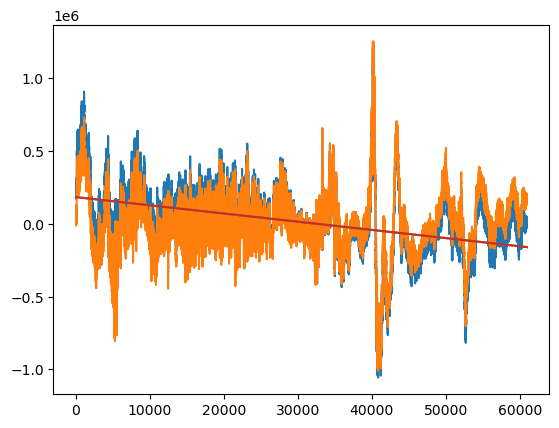

In [87]:
plt.plot(ex_slices[0])
plt.plot(ex_slices_dt[0])
plt.plot(ex_l_trend[0, 0]*it + ex_l_trend[1, 0])
plt.plot(ex_slices[0] - ex_slices_dt[0])

In [88]:
window = sig.windows.hamming(ex_slices.shape[-1])

In [89]:
Ex = np.fft.rfft(ex_slices_dt * window)[...,1:]  # the [1:] portion cuts off the zero frequency
Ey = np.fft.rfft(ey_slices_dt * window)[...,1:]

Hx = np.fft.rfft(hx_slices_dt * window)[...,1:]
Hy = np.fft.rfft(hy_slices_dt * window)[...,1:]
Hz = np.fft.rfft(hz_slices_dt * window)[...,1:]

f = np.fft.rfftfreq(ex_slices.shape[-1], 1)[1:]

In [90]:
omega = 2 * np.pi * f
_, e_lowpass = sig.freqs_zpk(**nims_low_pass_e, worN=omega)
_, e_highpass = sig.freqs_zpk(**nims_high_pass_e, worN=omega)

_, h_lowpass = sig.freqs_zpk(**nims_low_pass_h, worN=omega)

In [91]:
Ex_cal = Ex / (e_gain * dipole_length * e_lowpass * e_highpass)
Ey_cal = Ey / (e_gain * dipole_length * e_lowpass * e_highpass)

Hx_cal = Hx / (h_gain * h_lowpass)
Hy_cal = Hy / (h_gain * h_lowpass)
Hz_cal = Hz / (h_gain * h_lowpass)

In [92]:
import functools

In [93]:
def Z_xy_func(Ex, Hx, Hy, Rx=None, Ry=None):
    if Rx is None:
        Rx = Hx
    if Ry is None:
        Ry = Hy
    Rxc = Rx.conjugate()
    Ryc = Ry.conjugate()

    r_sum = functools.partial(np.sum, axis=0)

    top_xy = r_sum(Ex * Ryc) * r_sum(Hx * Rxc) - r_sum(Ex * Rxc) * r_sum(Hx * Ryc)
    bot = r_sum(Hx * Rxc) * r_sum(Hy * Ryc) - r_sum(Hx * Ryc) * r_sum(Hy * Rxc)

    return top_xy / bot

def Z_yx_func(Ey, Hx, Hy, Rx=None, Ry=None):
    if Rx is None:
        Rx = Hx
    if Ry is None:
        Ry = Hy
    Rxc = Rx.conjugate()
    Ryc = Ry.conjugate()

    r_sum = functools.partial(np.sum, axis=0)

    top_xy = r_sum(Ex * Ryc) * r_sum(Hx * Rxc) - r_sum(Ex * Rxc) * r_sum(Hx * Ryc)
    bot = r_sum(Hx * Rxc) * r_sum(Hy * Ryc) - r_sum(Hx * Ryc) * r_sum(Hy * Rxc)

    return top_xy / bot

In [94]:
Z_xy = Z_xy_func(Ex_cal, Hx_cal, Hy_cal)


In [95]:
rho_a = 1/(mu_0 * omega) * np.abs(Z_xy)**2

(1, 10000.0)

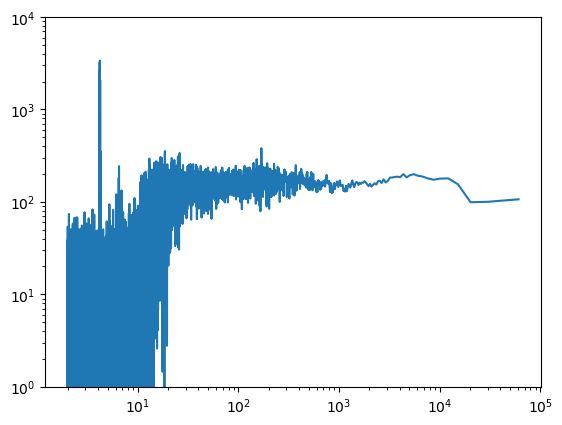

In [99]:
plt.loglog(1/f, rho_a)
#plt.xlim([1E1, 1E3])
plt.ylim([1, 1E4])

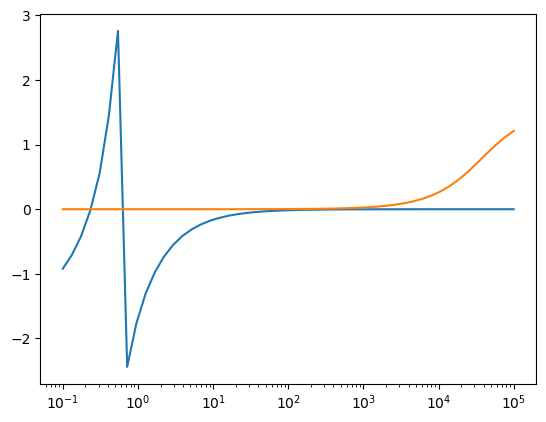

In [30]:
plt.semilogx(T, np.angle(h_l))
plt.semilogx(T, np.angle(h_h))